In [1]:
from parse_full_results import get_full_try_exps_dataframe
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 3
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['axes.titlesize']=12
plt.rcParams['axes.labelsize']=12
plt.rcParams['figure.figsize'] = (8.0, 8.0)
plt.rcParams['font.size'] = 14

plt.rcParams['axes.formatter.use_locale'] = True

In [2]:
df = get_full_try_exps_dataframe()

In [3]:
columns = df.columns
df.rename(columns = {'class':'model_class', 'num_samples':'samples_num'}, inplace=True)
df

,model_class,train_loss,val_loss,train_acc,val_acc,deviation,save_log_path,num_epochs,loader_size,layers_num,hidden_channels,kernel_size,output_channels,num_params,sigma,samples_num
0,conv,0.820361,0.911670,0.713075,0.682524,0.104189,results/hc512/4_22,2,-1,4,512,3,8,7202642,3,32
1,conv,0.275363,0.851077,0.912724,0.738854,0.061713,results/hc512/7_17,8,-1,3,512,3,8,4842834,3,32
2,conv,1.427615,1.440004,0.502118,0.489053,0.117319,results/hc512/4_63,1,-1,10,512,3,8,21361490,3,32
3,conv,0.068190,1.268307,0.976103,0.744228,0.033159,results/hc512/4_60,16,-1,9,512,3,8,19001682,3,32
4,conv,0.829290,0.936554,0.706102,0.663913,0.096814,results/hc512/5_72,4,-1,11,512,3,8,23721298,3,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3483,conv,0.930145,1.007190,0.676830,0.644407,0.125236,results/hc_128/3_8,2,-1,2,128,3,8,232402,3,32
3484,conv,0.865797,0.968462,0.695672,0.658041,0.107092,results/hc_128/1_79,4,-1,12,128,3,8,1708242,3,32
3485,conv,0.907774,0.968075,0.682984,0.659733,0.106119,results/hc_128/6_22,2,-1,4,128,3,8,527570,3,32
3486,conv,0.045660,1.780323,0.983516,0.752986,0.035066,results/hc_128/1_33,32,-1,5,128,3,8,675154,3,32


In [4]:
def describe_exps(df, describe_in_column = None):
    if describe_in_column is not None:
        final_rows = []
        for target_col in np.unique(df[describe_in_column]):
            current_row = {describe_in_column:target_col}
            for column in ['num_epochs', 'layers_num', 'hidden_channels']:
                if column == describe_in_column:
                    continue
                current_row[f'unique {column}'] = len(np.unique(np.array(df.query(f'{describe_in_column} == {target_col}')[column])))
            final_rows.append(current_row)
        print(current_row.keys())
        display(pd.DataFrame(final_rows, columns = current_row.keys()))
    else:
        print(f'number of unique')
        for column in ['num_epochs', 'layers_num', 'hidden_channels']:
            print(column, ':', len(np.unique(np.array(df[column]))))
print()
describe_exps(df, describe_in_column='layers_num')
describe_exps(df, describe_in_column='hidden_channels')


dict_keys(['layers_num', 'unique num_epochs', 'unique hidden_channels'])


,layers_num,unique num_epochs,unique hidden_channels
0,1,7,7
1,2,7,6
2,3,7,6
3,4,7,6
4,5,7,5
5,6,7,4
6,7,7,4
7,8,7,4
8,9,7,4
9,10,7,4


dict_keys(['hidden_channels', 'unique num_epochs', 'unique layers_num'])


,hidden_channels,unique num_epochs,unique layers_num
0,64,7,16
1,128,7,16
2,256,7,14
3,512,7,15
4,1024,7,5
5,2048,7,4
6,4096,7,1


deviation = $mean_k((k+1)|\mathcal{L}_{k+1} - \mathcal{L}_k|)$ <br>
При этом данная величина усреднена по запускам (по 8 для каждого сетапа)

In [5]:
def compare_same_params(same_params_dict, 
                        target_params, 
                        supported_changes_params, 
                        df = df, 
                        enable_valid = True,
                        params_in_suptitle = None,
                        train_log_columns = ['train_loss', 'val_loss', 'train_acc', 'val_acc']):
    columns = list(same_params_dict.keys()) + [target_params] + ['deviation'] + train_log_columns + [supported_changes_params]
    def wrap(elem):
        if isinstance(elem, str):
            elem = '\"' + elem + '\"'
        return elem
    query = ' and '.join([f'{key} == {wrap(value)}' for key, value in same_params_dict.items()])
    df = df[columns].query(query)
    fig, axs = plt.subplots(3, figsize = (15, 12))
    if params_in_suptitle is not None:
        fig.suptitle([f'{key}:{same_params_dict[key]}' for key in params_in_suptitle])
    colors = sns.color_palette()
    mod = len(colors)
    for i, supported_param in enumerate(np.unique(df[supported_changes_params])):
        df_with_supported = copy.deepcopy(df)
        df_with_supported.query(f'{supported_changes_params} == {supported_param}', inplace = True)
        sns.pointplot(
            x=target_params, 
            y='deviation',
            data=df_with_supported, ax = axs[0], 
            label = supported_param, 
            color = colors[i%mod])
        if 'train_loss' in train_log_columns:
            sns.pointplot(
                x=target_params, 
                y='train_loss', 
                data=df_with_supported, ax = axs[1], 
                label = f'{supported_param}',
                color = colors[i%mod]);
        if 'val_loss' in train_log_columns:
            if enable_valid:
                sns.pointplot(
                    x=target_params, 
                    y='val_loss', 
                    data=df_with_supported, ax = axs[1],
                    color = colors[i%mod]);
        if 'train_acc' in train_log_columns:
            sns.pointplot(
                x=target_params, 
                y='train_acc', 
                data=df_with_supported, 
                ax = axs[2], 
                label= f'{supported_param}',
                color = colors[i%mod]
            );
        if 'val_acc' in train_log_columns:
            if enable_valid:
                sns.pointplot(
                    x=target_params, 
                    y='val_acc', 
                    data=df_with_supported, 
                    ax = axs[2], 
                    color = colors[i%mod]);

    for i in range(3):
        axs[i].legend(title = supported_changes_params)
    axs[1].set_ylabel('Loss')
    axs[2].set_ylabel('Accuracy')


#### Строю train/valid, при этом одним цветом помечаю одну и ту же модель для train и valid <br>
Отдаельно не подписываю valid

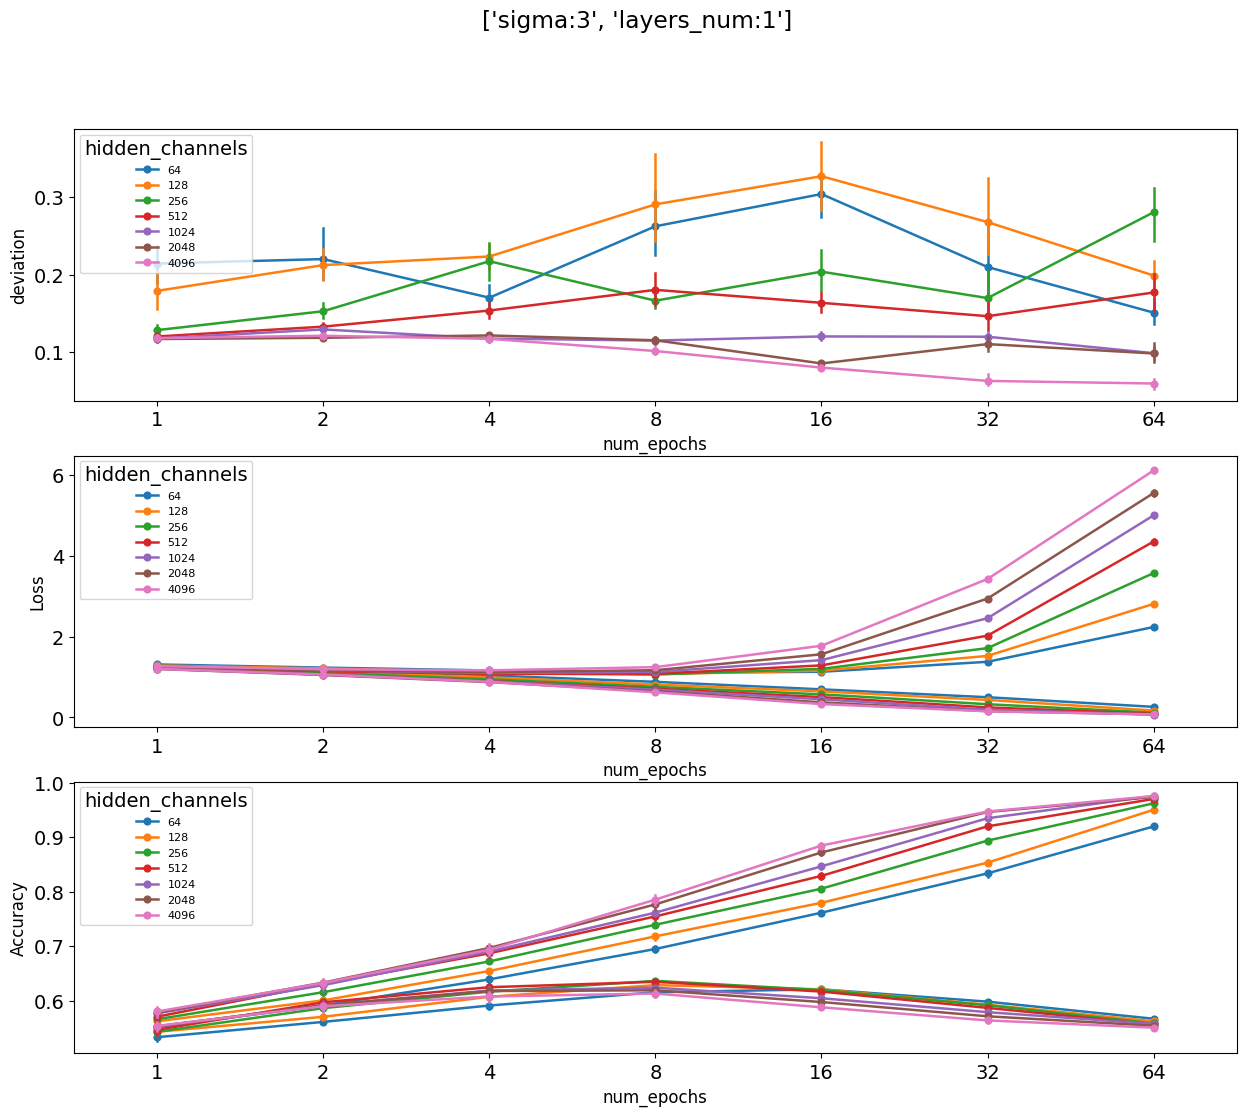

In [6]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':1,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'
compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params, 
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

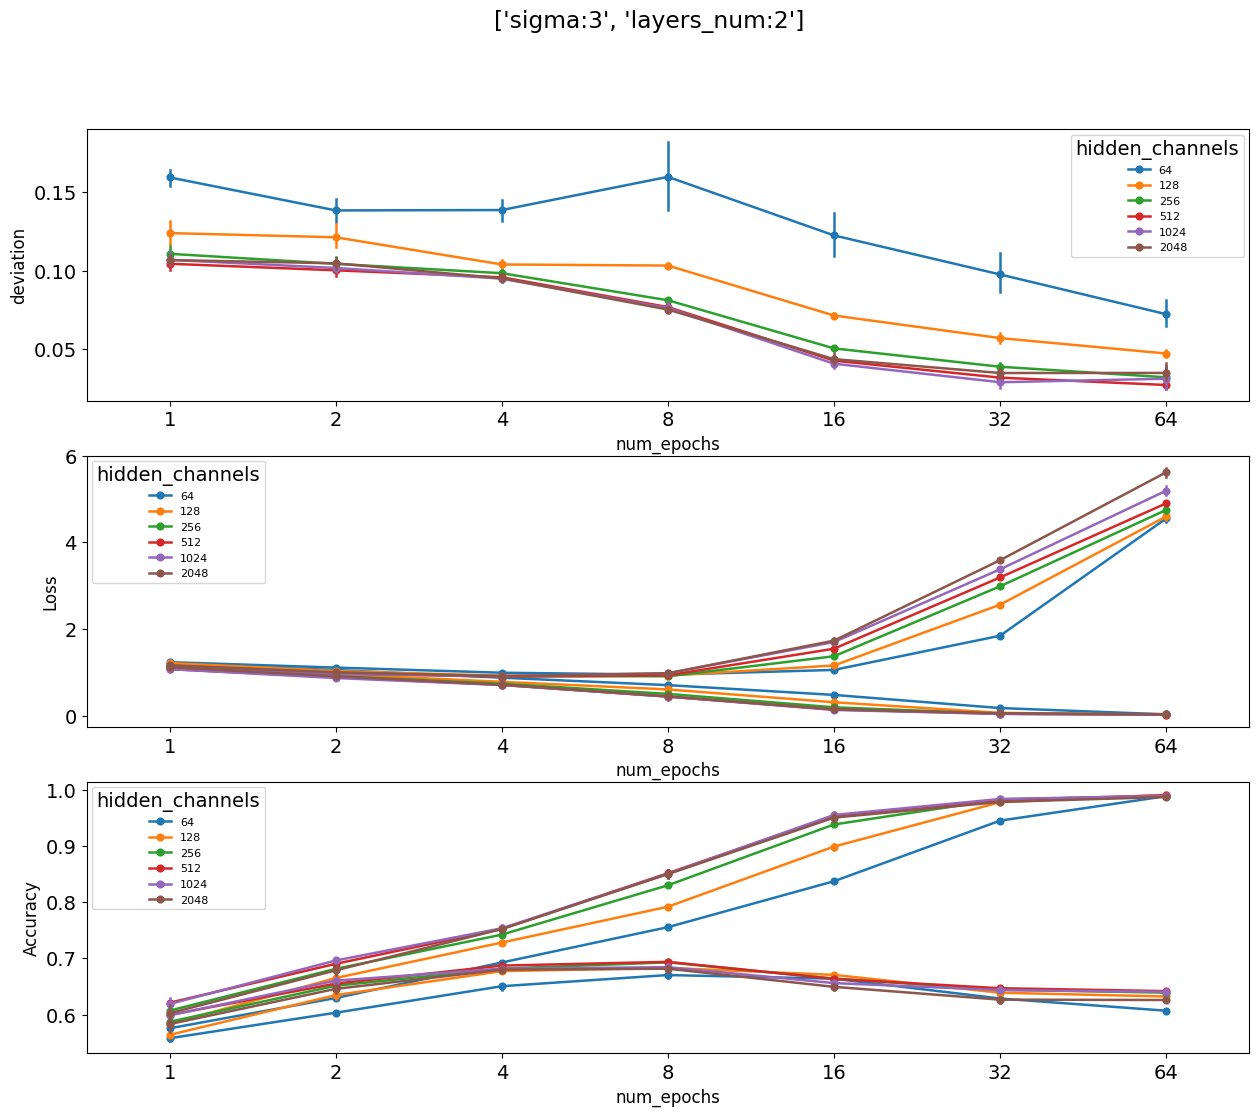

In [7]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':2,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params, 
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

In [8]:
df.query('layers_num == 8 and num_epochs == 8 and hidden_channels == 256')

,model_class,train_loss,val_loss,train_acc,val_acc,deviation,save_log_path,num_epochs,loader_size,layers_num,hidden_channels,kernel_size,output_channels,num_params,sigma,samples_num
1213,conv,0.287277,0.755716,0.903073,0.759952,0.064745,results/hc_256/4_52,8,-1,8,256,3,8,4228178,3,32
1235,conv,0.304809,0.783308,0.894182,0.749204,0.066730,results/hc_256/5_52,8,-1,8,256,3,8,4228178,3,32
1267,conv,0.320175,0.714111,0.892543,0.762440,0.066057,results/hc_256/7_52,8,-1,8,256,3,8,4228178,3,32
1358,conv,0.287135,0.738439,0.906989,0.755374,0.057830,results/hc_256/0_52,8,-1,8,256,3,8,4228178,3,32
1384,conv,0.311836,0.766130,0.893322,0.763336,0.070906,results/hc_256/1_52,8,-1,8,256,3,8,4228178,3,32
1425,conv,0.278589,0.720339,0.908108,0.766620,0.060177,results/hc_256/6_52,8,-1,8,256,3,8,4228178,3,32
1502,conv,0.313146,0.728518,0.899317,0.760549,0.060928,results/hc_256/3_52,8,-1,8,256,3,8,4228178,3,32
1517,conv,0.240758,0.730919,0.920736,0.770402,0.057012,results/hc_256/2_52,8,-1,8,256,3,8,4228178,3,32


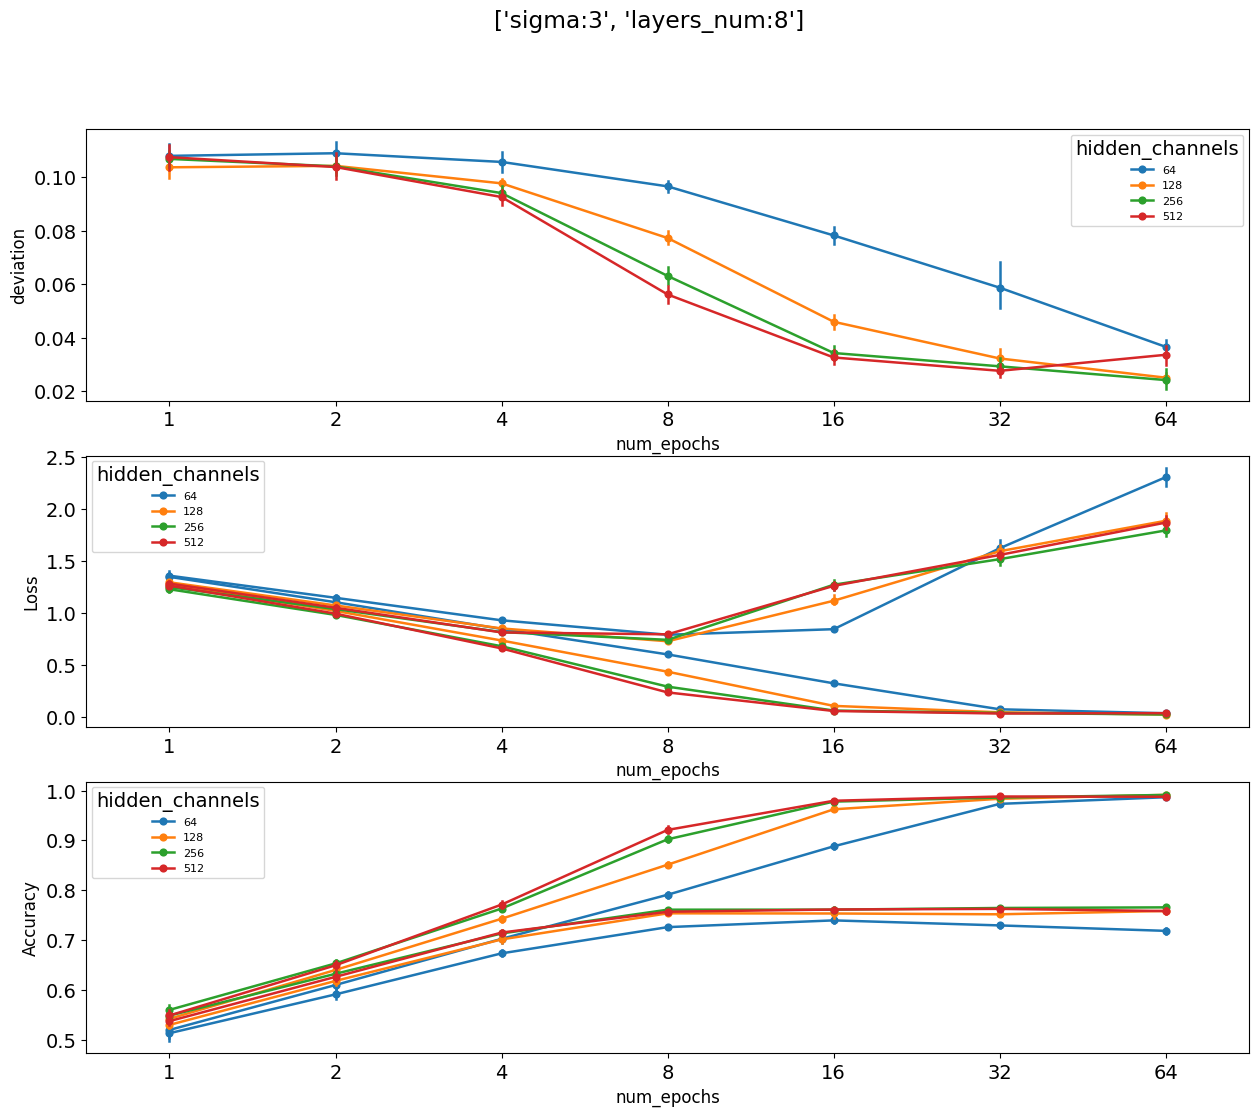

In [9]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':8,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params, 
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

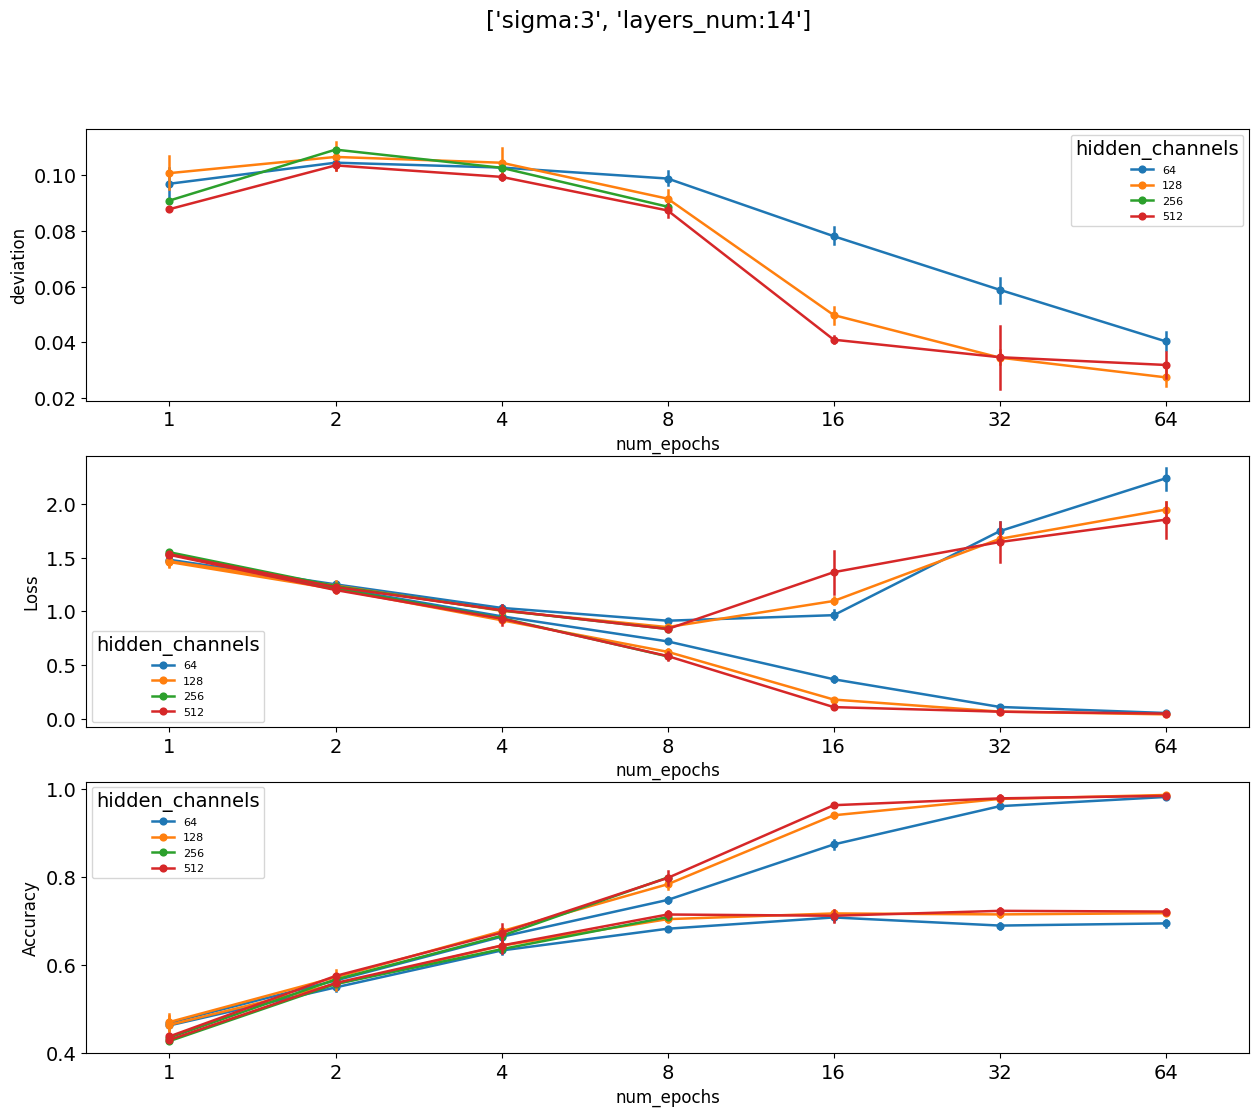

In [10]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':14,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'hidden_channels'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

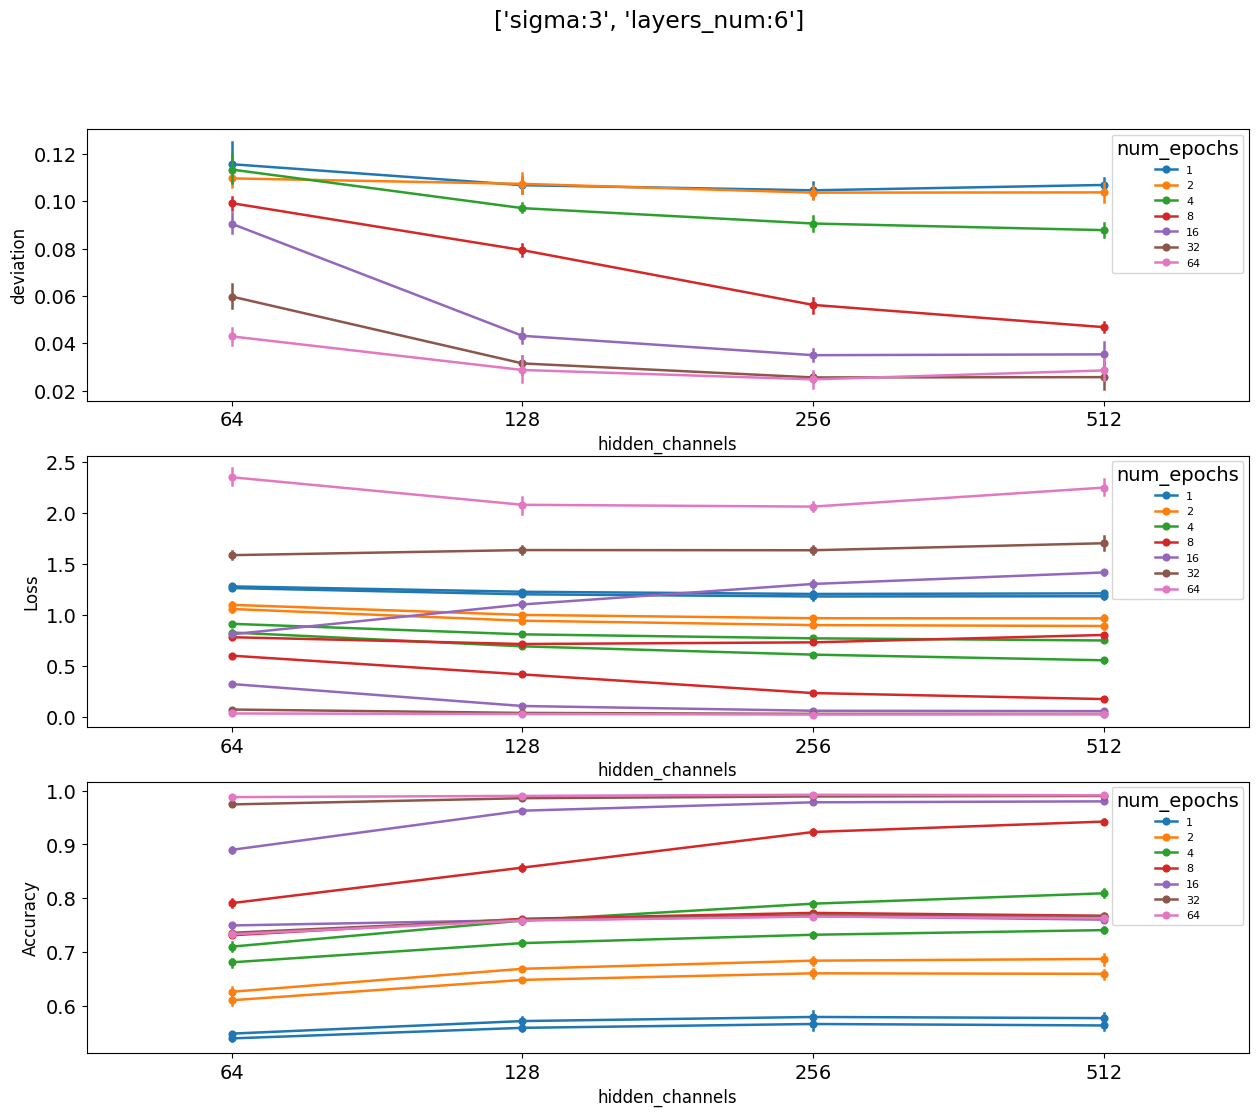

In [11]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'layers_num':6,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'hidden_channels'
supported_changes_params = 'num_epochs'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'layers_num'])

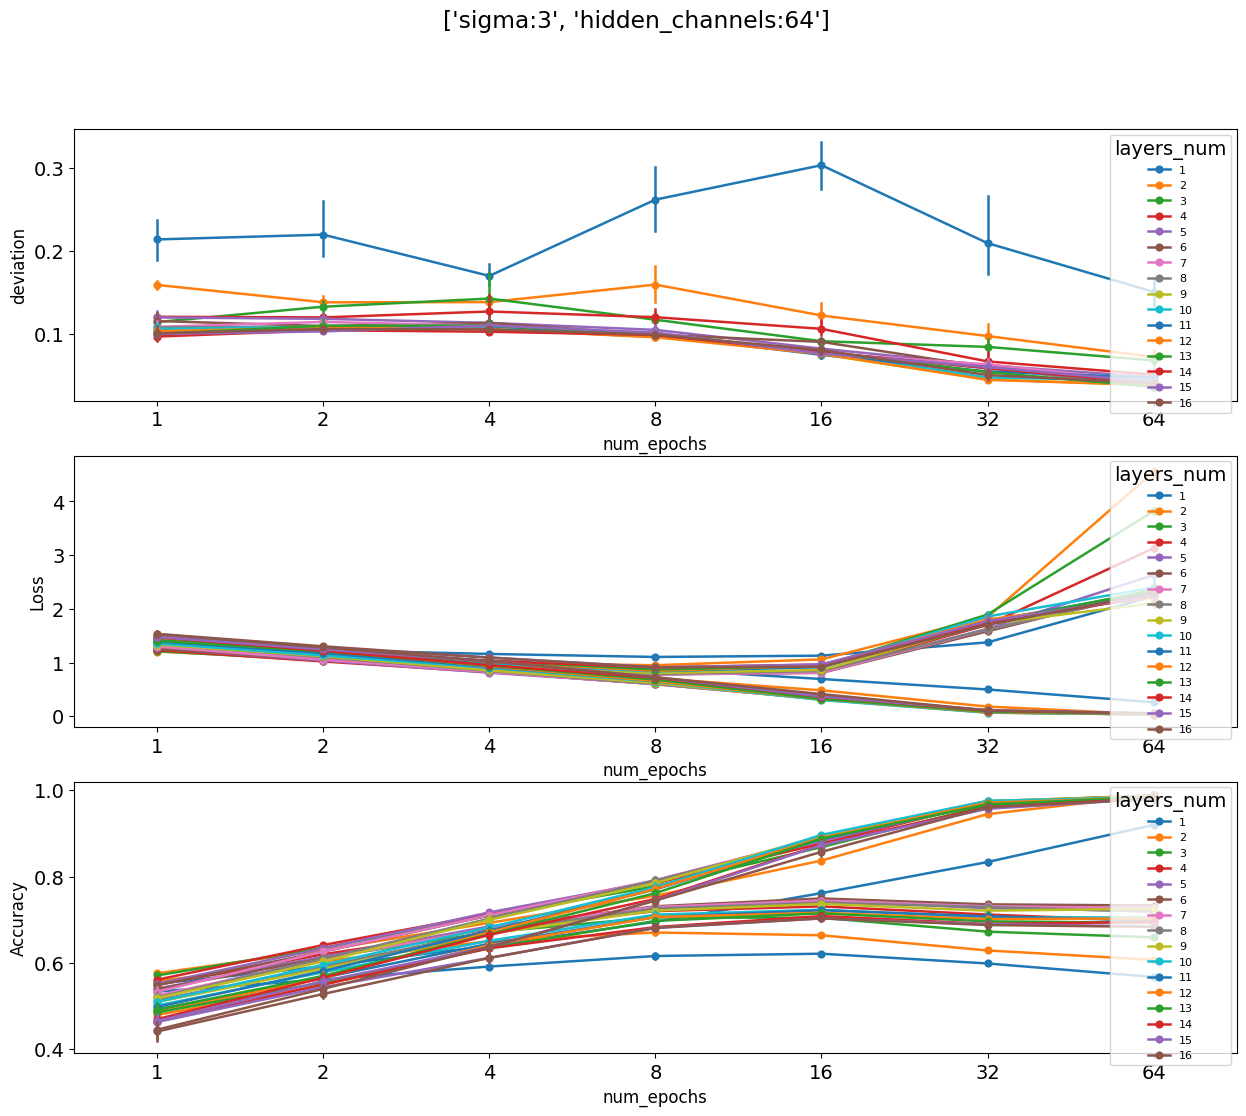

In [12]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':64,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

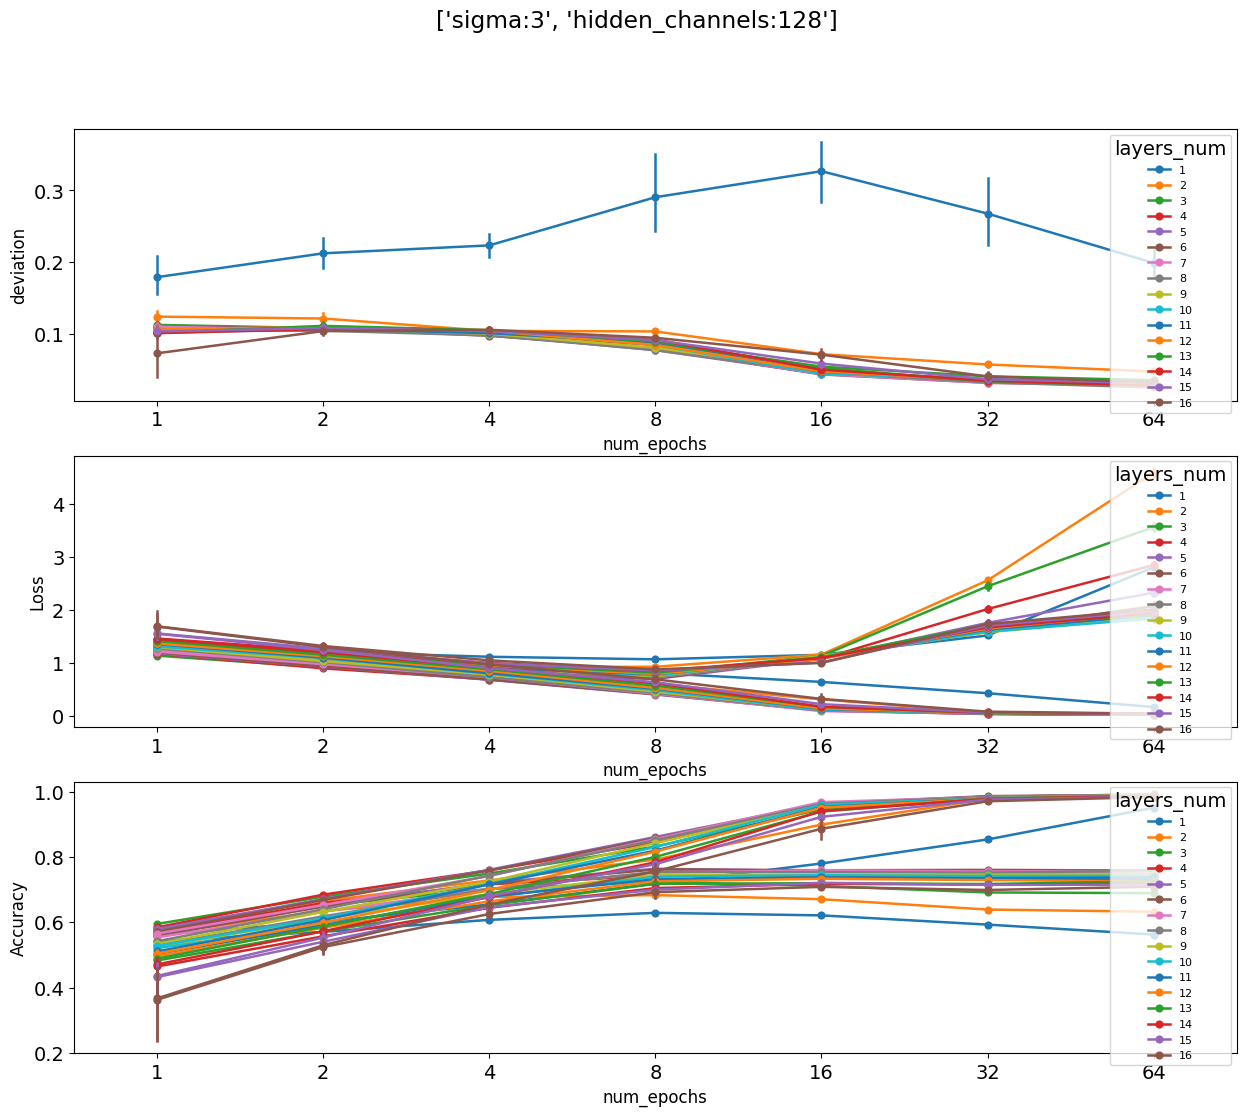

In [13]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':128,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

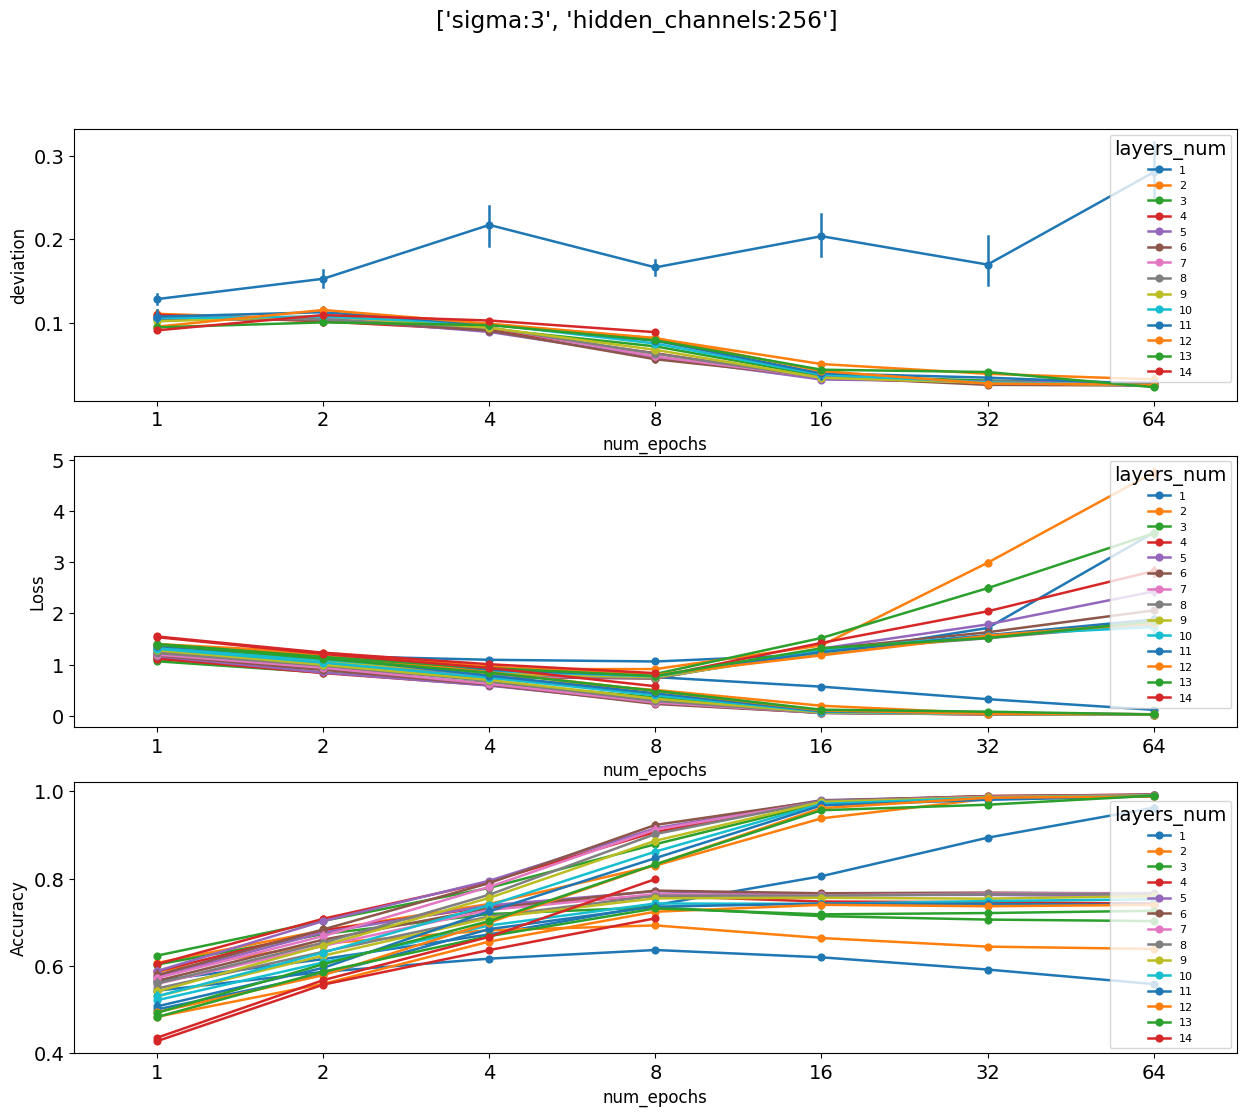

In [14]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':256,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

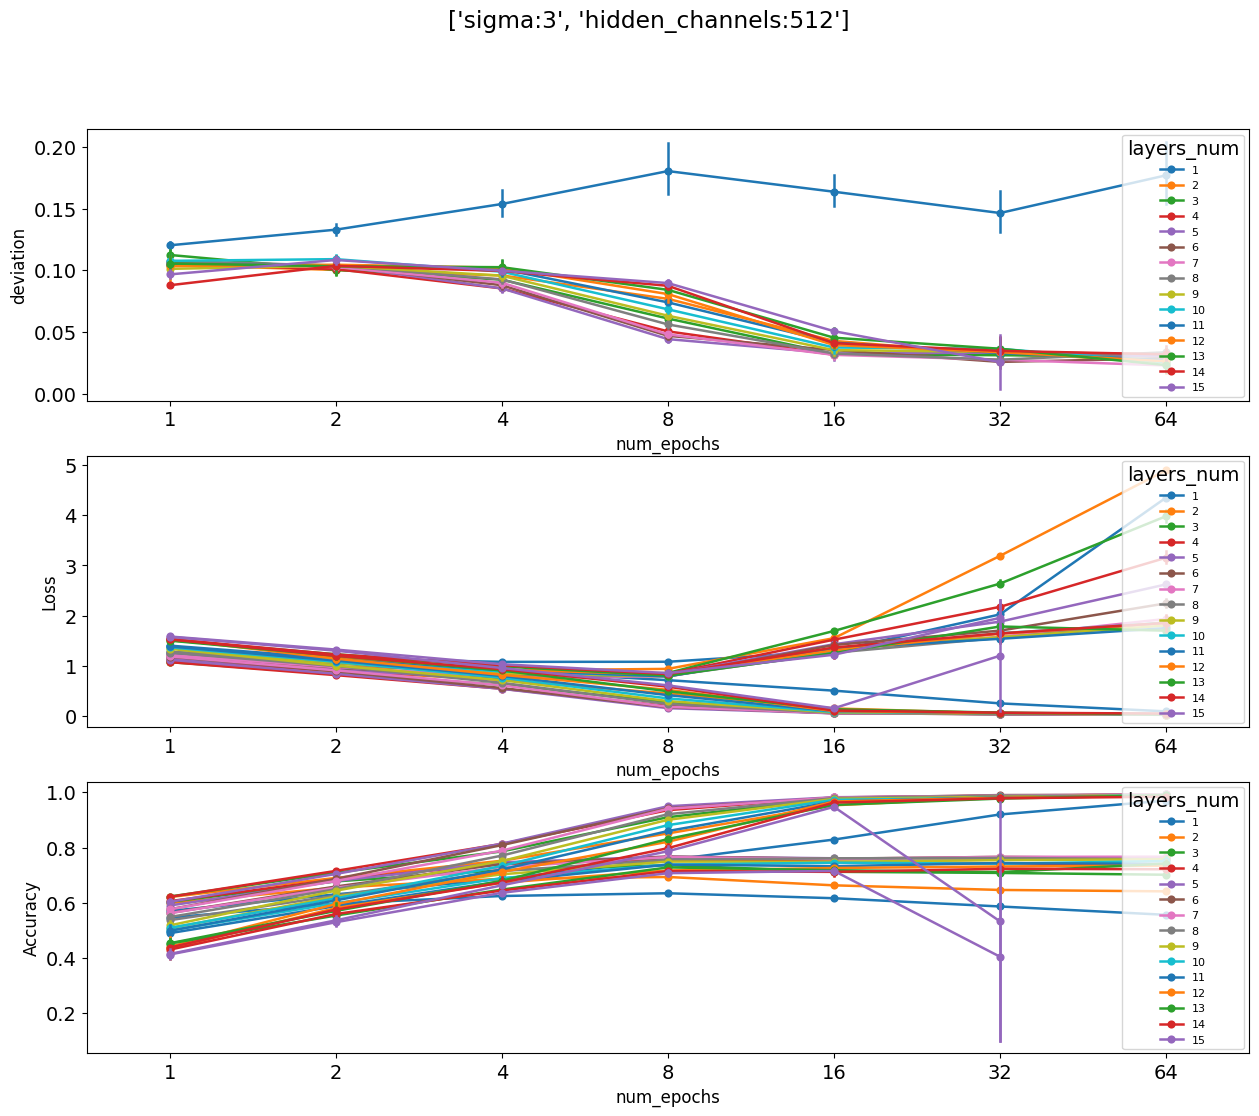

In [15]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':512,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

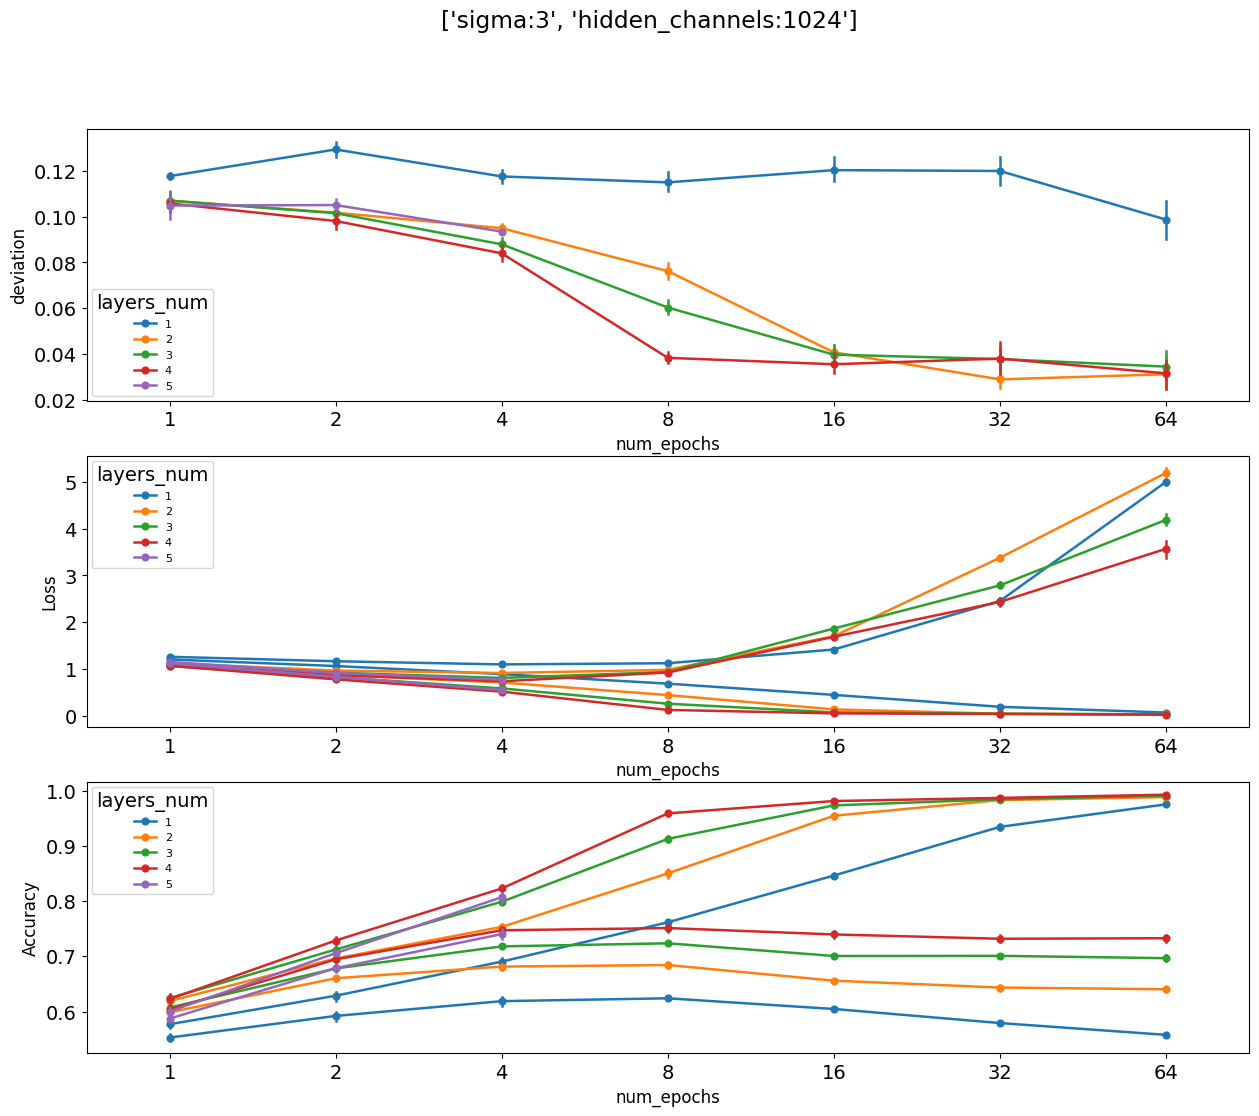

In [16]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':1024,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'num_epochs'
supported_changes_params = 'layers_num'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

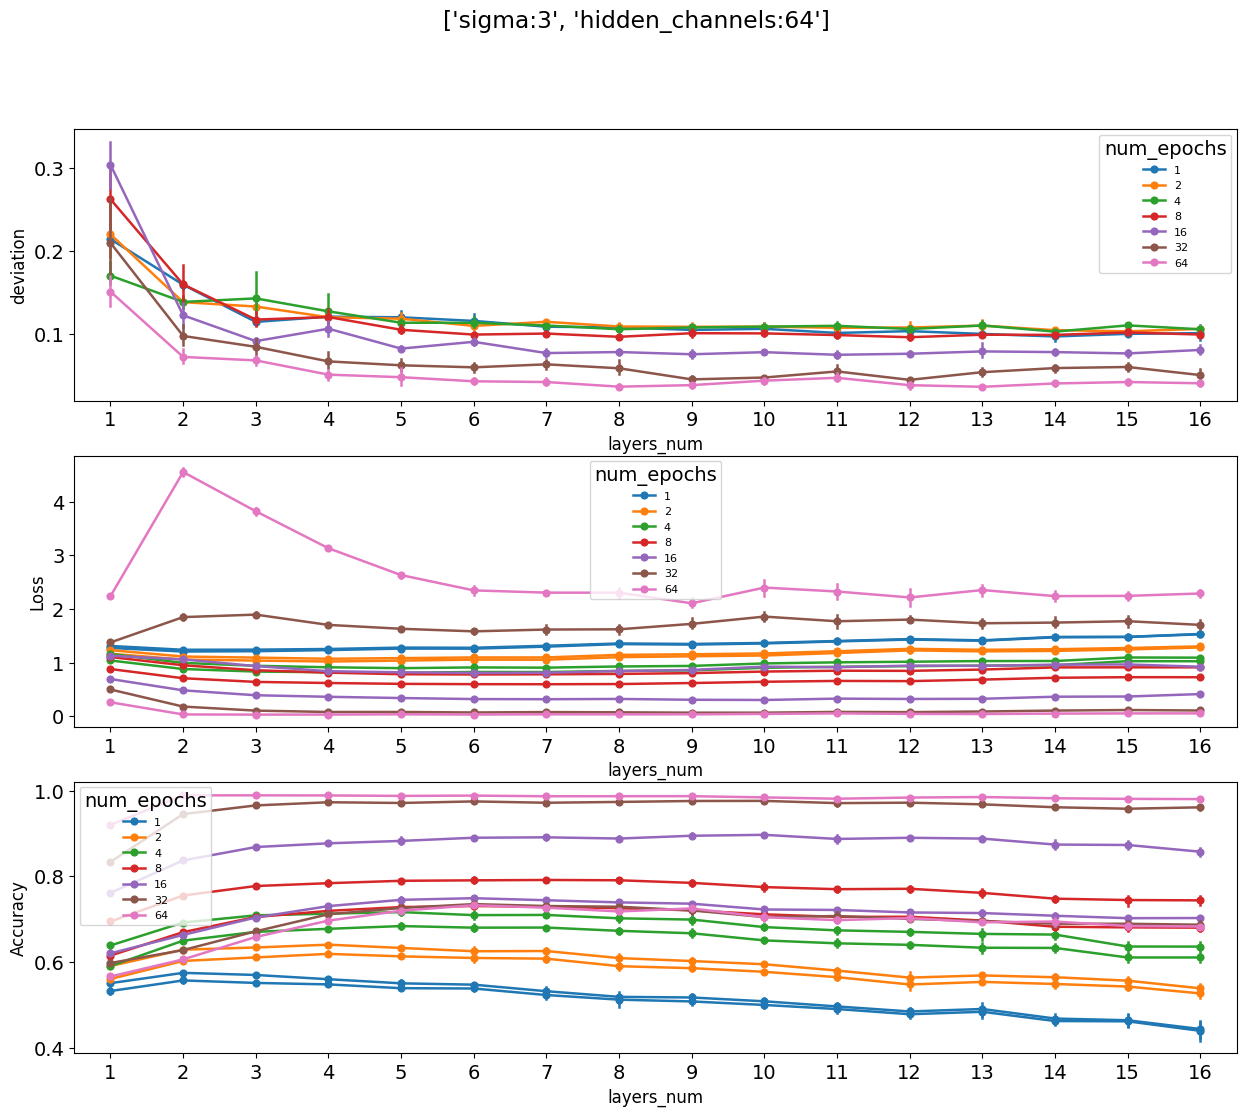

In [17]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':64,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'layers_num'
supported_changes_params = 'num_epochs'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

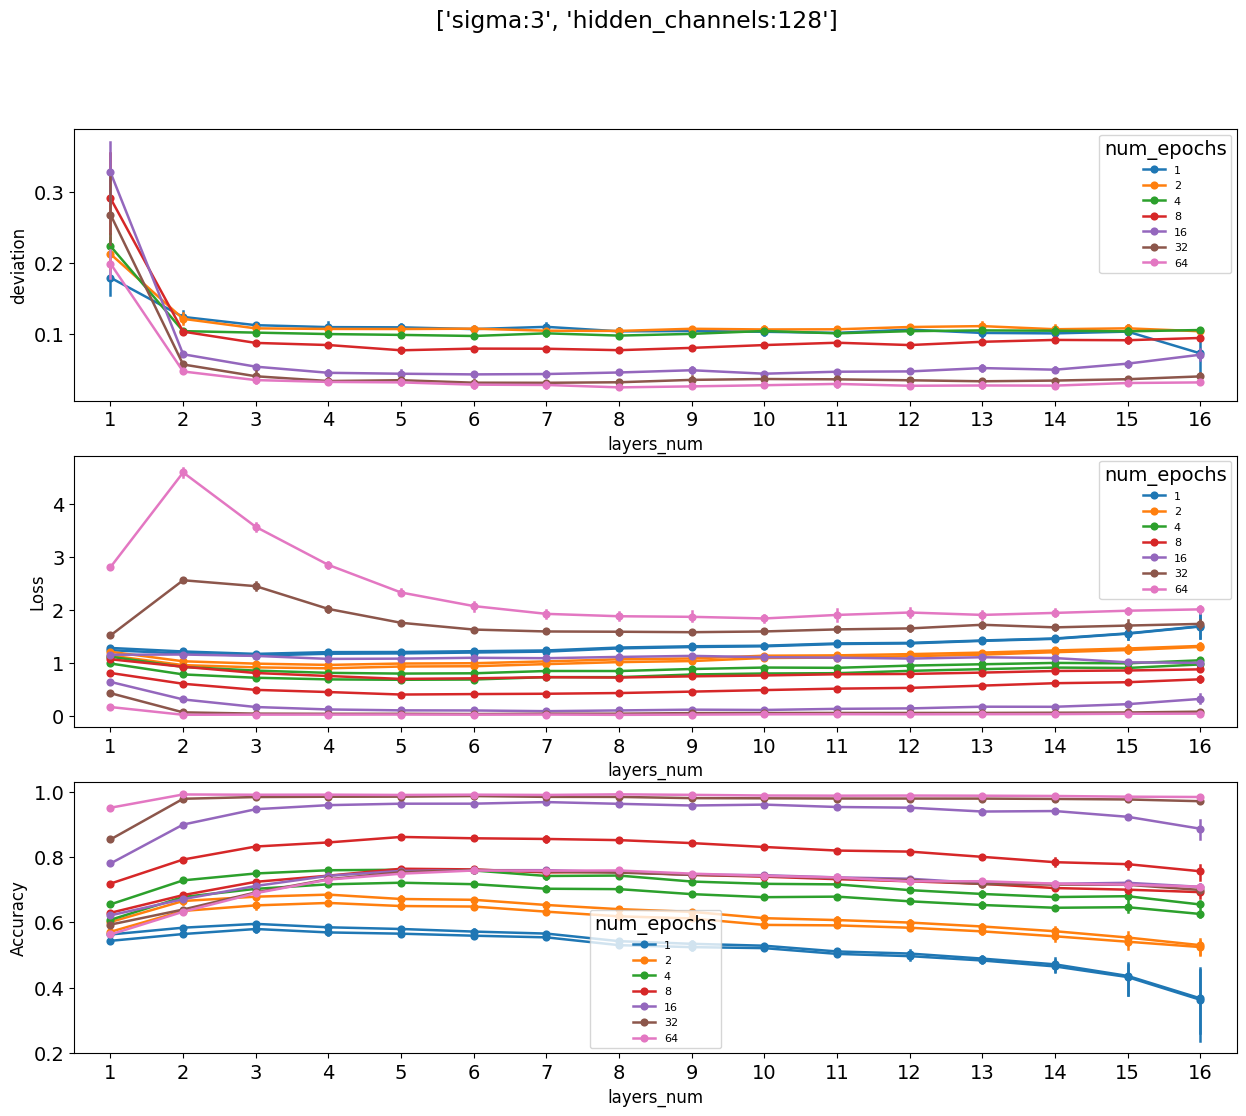

In [18]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':128,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'layers_num'
supported_changes_params = 'num_epochs'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

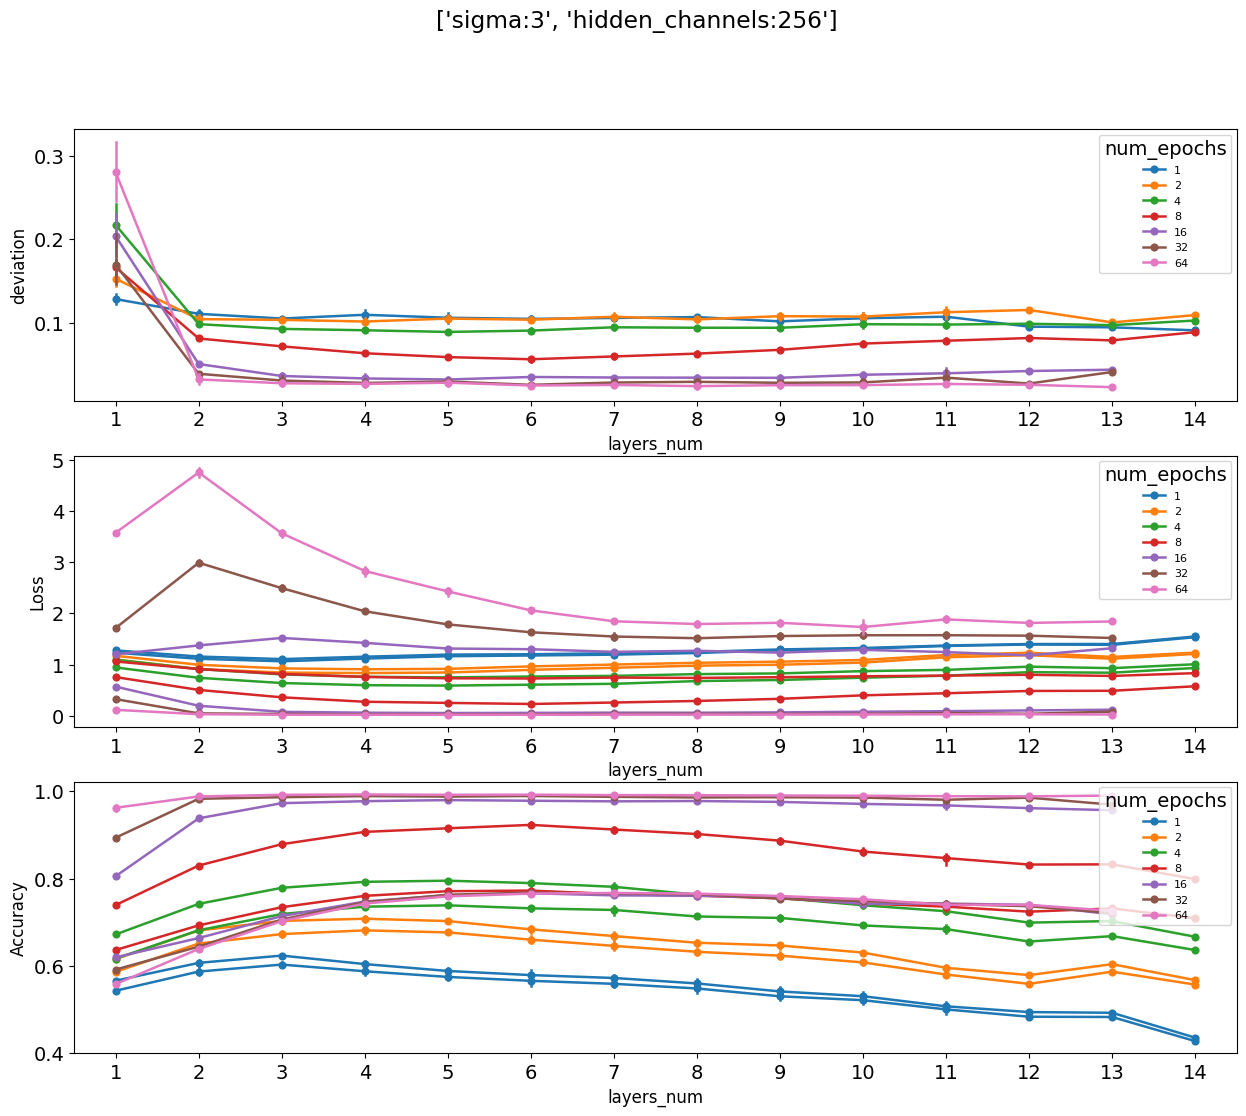

In [19]:
same_params = {
    'model_class':'conv',
    
    'loader_size':-1,
    'hidden_channels':256,
    'kernel_size':3,
    'output_channels':8,
    'sigma':3,
    'samples_num':32
}
target_params = 'layers_num'
supported_changes_params = 'num_epochs'

compare_same_params(same_params, 
                    target_params, 
                    supported_changes_params,
                    enable_valid=True, 
                    params_in_suptitle=['sigma', 'hidden_channels'])

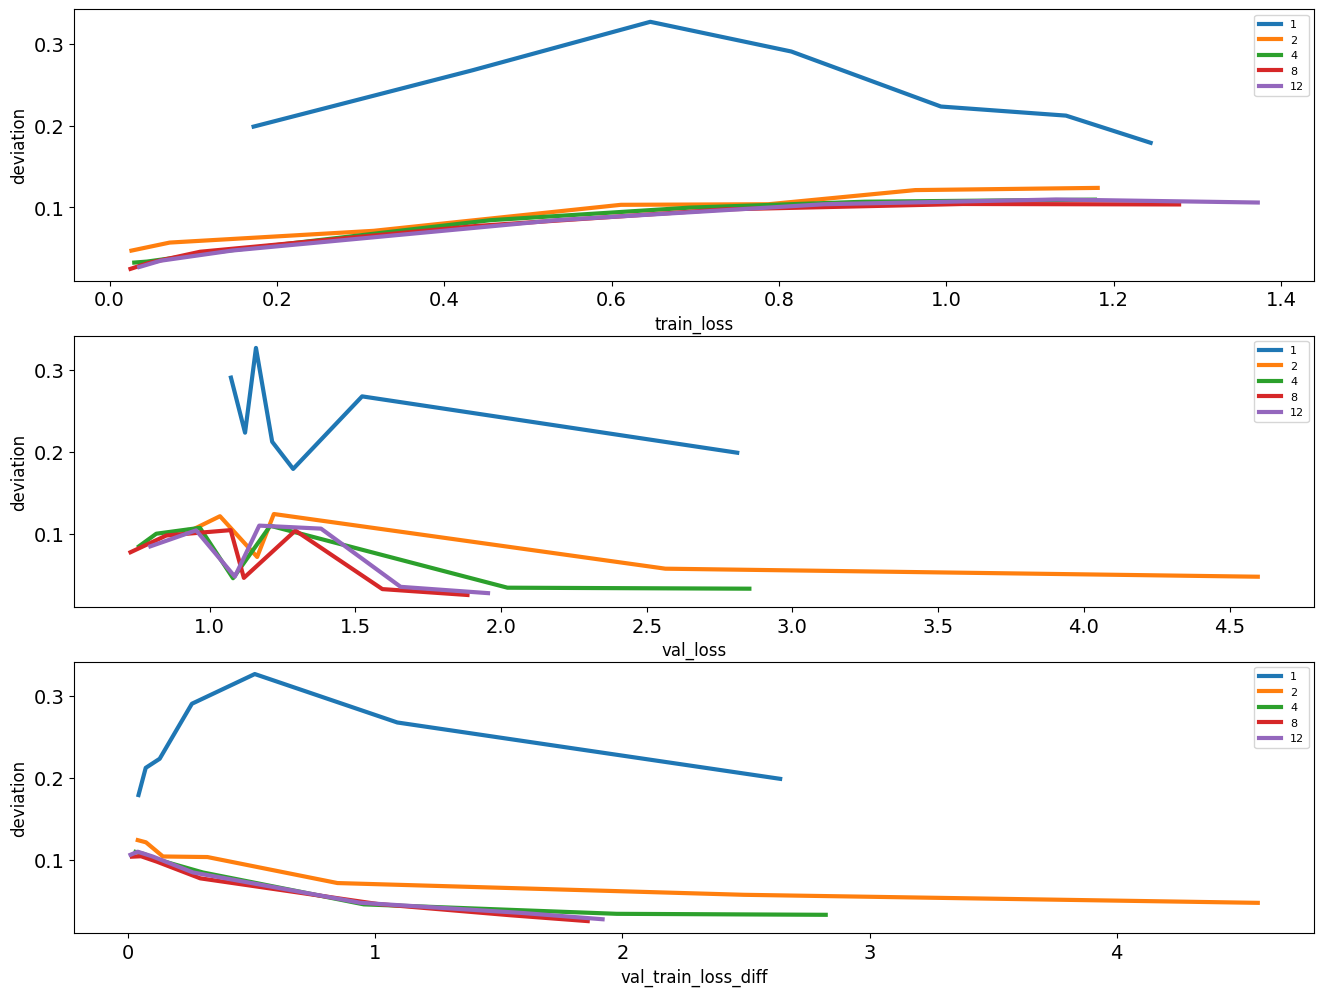

In [117]:
fig, axs = plt.subplots(3, figsize = (16, 12))
for i, l in enumerate([1, 2, 4, 8, 12]):
    t = df.query(f'layers_num == {l} and hidden_channels == 128')[['num_epochs', 'train_loss', 'val_loss', 'deviation', 'hidden_channels']]
    t = t.groupby(['num_epochs', 'hidden_channels']).mean().reset_index()
    t['val_train_loss_diff'] = t.val_loss - t.train_loss
    sns.lineplot(data = t, x = 'train_loss', y = 'deviation', label = f'{l}', ax = axs[0], lw = 3)
    sns.lineplot(data = t, x = 'val_loss', y = 'deviation', label = f'{l}', ax = axs[1], lw = 3)
    sns.lineplot(data = t, x = 'val_train_loss_diff', y = 'deviation', label = f'{l}', ax = axs[2], lw = 3)

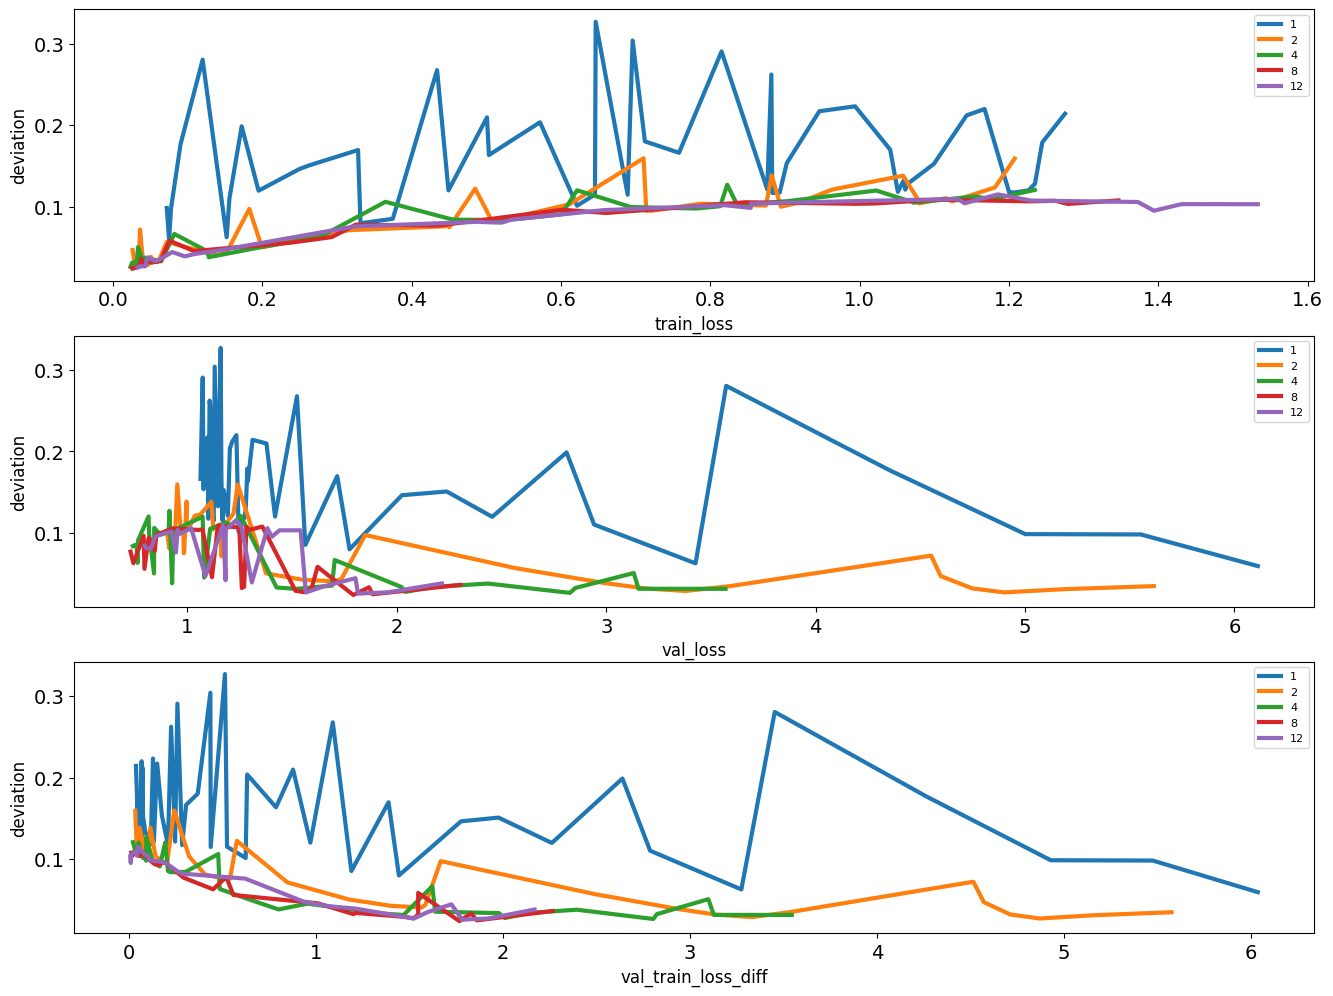

In [113]:
fig, axs = plt.subplots(3, figsize = (16, 12))
for i, l in enumerate([1, 2, 4, 8, 12]):
    t = df.query(f'layers_num == {l}')[['num_epochs', 'train_loss', 'val_loss', 'deviation', 'hidden_channels']]
    t = t.groupby(['num_epochs', 'hidden_channels']).mean().reset_index()
    t['val_train_loss_diff'] = t.val_loss - t.train_loss
    sns.lineplot(data = t, x = 'train_loss', y = 'deviation', label = f'{l}', ax = axs[0], lw = 3)
    sns.lineplot(data = t, x = 'val_loss', y = 'deviation', label = f'{l}', ax = axs[1], lw = 3)
    sns.lineplot(data = t, x = 'val_train_loss_diff', y = 'deviation', label = f'{l}', ax = axs[2], lw = 3)